<a href="https://colab.research.google.com/github/hetanshipatel/healthcare-ai-modelling-framework/blob/main/notebooks/healthcare_ai_modelling_framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01_data_exploration.ipynb
## Computational Decision Modeling Framework

**Objective:**  
This notebook demonstrates the first step in building a research-grade AI framework: programmatic dataset acquisition, loading, and initial exploration.  

**Dataset:**  
- Heart Disease Dataset (Kaggle: johnsmith88/heart-disease-dataset)  
- Domain: Healthcare / Risk Modelling  

**Purpose:**  
1. Setup Kaggle API credentials for reproducible dataset access  
2. Download dataset programmatically  
3. Load CSV into Pandas DataFrame  
4. Perform basic exploratory data analysis (EDA)  
5. Visualize target distribution  

This notebook provides the foundation for subsequent preprocessing, feature engineering, and machine learning modeling.

In [16]:
# Step 1: Setup Kaggle API in Colab
# Using environment variable to store API key securely
# This ensures reproducible dataset downloads without manual uploads
import os

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_ed3b067ca6163c2d2af7ac4b9226ac69'

In [3]:
# Step 2: Install Kaggle CLI package
# Required to download datasets programmatically
!pip install kaggle --quiet

In [4]:
# Step 3: Create kaggle.json credentials file
# Kaggle CLI expects credentials to be in /root/.kaggle/kaggle.json
import json

os.makedirs("/root/.kaggle", exist_ok=True)

kaggle_json = {
    "username": "hetanshipatel72 ",
    "key": os.environ['KAGGLE_API_TOKEN']
}

# Write kaggle.json file
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_json, f)

# Set permissions
os.chmod("/root/.kaggle/kaggle.json", 600)

In [5]:
# Step 4: Download dataset via Kaggle API
# -p data : store in 'data/' folder
# --unzip : automatically extract the zip file
# This ensures workflow reproducibility
!kaggle datasets download -d johnsmith88/heart-disease-dataset -p data --unzip

Dataset URL: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
License(s): unknown
100% 6.18k/6.18k [00:00<00:00, 9.38MB/s]



In [6]:
# Step 5: Load CSV dataset into Pandas DataFrame
# This is essential for initial exploration and preprocessing
import pandas as pd

df = pd.read_csv("data/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [7]:
# Step 6: Examine the dataset structure
# - Info about columns, data types
# - Missing values
# - Summary statistics
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# Data Preprocessing & Feature Exploration

This section focuses on preparing the dataset for machine learning by handling missing values, ensuring correct data types, and exploring feature relationships.

Proper preprocessing is critical for building reliable and generalizable models.

In [8]:
# Step 7: Handle Missing Values

# In this dataset, missing values are represented as '?'
# Replace them with NaN for proper handling
df.replace('?', pd.NA, inplace=True)

# Convert all columns to numeric where possible
df = df.apply(pd.to_numeric, errors='coerce')

# Check missing values again
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [9]:
# Step 8: Handle missing values (simple strategy)

# Fill missing values with median (robust for healthcare data)
df.fillna(df.median(numeric_only=True), inplace=True)

# Verify no missing values remain
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


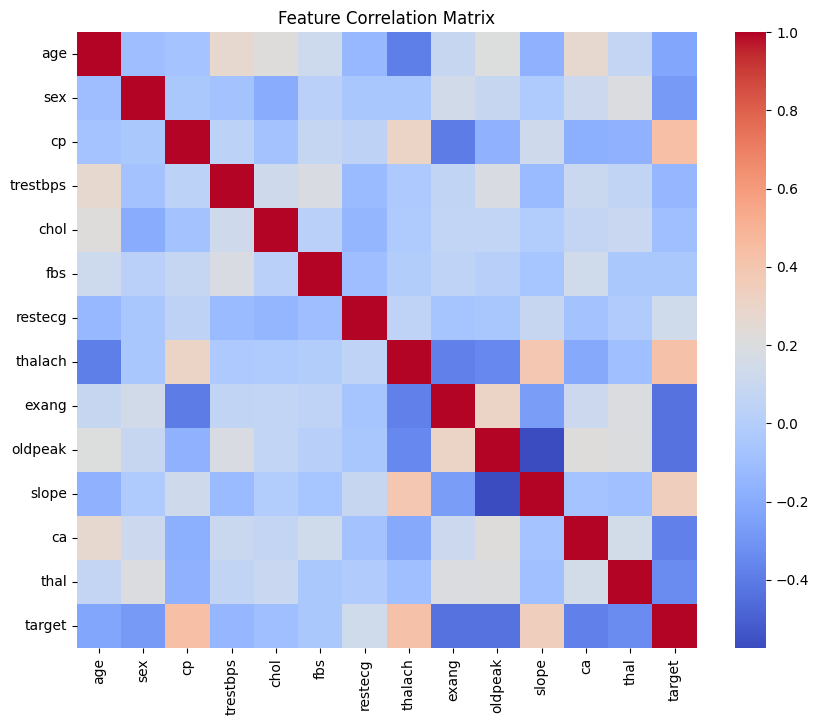

In [10]:
# Step 9: Correlation Analysis

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [11]:
# Step 10: Feature relationship with target

# Correlation with target variable
target_corr = df.corr()['target'].sort_values(ascending=False)
print(target_corr)

target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64


# Baseline Machine Learning Model

In this section, we train a baseline model to evaluate whether the dataset contains predictive signal.

A baseline model provides a reference performance level before applying advanced modelling techniques.

In [12]:
# Step 11: Prepare features and target

X = df.drop('target', axis=1)
y = df['target']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (820, 13)
Test shape: (205, 13)


In [13]:
# Step 12: Train baseline Random Forest model

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [14]:
# Step 13: Evaluate model

from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9853658536585366
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



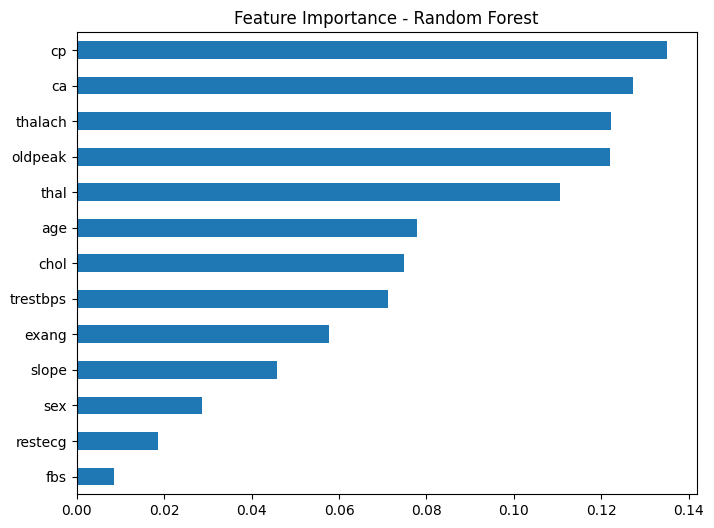

In [15]:
# Step 15: Feature importance analysis

import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Feature Importance - Random Forest")
plt.show()

# Advanced Model: XGBoost

In addition to the baseline Random Forest model, we train an XGBoost classifier to evaluate performance improvements using gradient boosting techniques.

Model comparison is essential in research to determine the most suitable predictive approach.

In [17]:
!pip install xgboost --quiet

In [18]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:45:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [19]:
from sklearn.metrics import accuracy_score

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.9170731707317074


In [20]:
rf_acc = accuracy_score(y_test, y_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)

print("Random Forest Accuracy:", rf_acc)
print("XGBoost Accuracy:", xgb_acc)

Random Forest Accuracy: 0.9853658536585366
XGBoost Accuracy: 0.9170731707317074


# Model Performance Interpretation

Interestingly, the Random Forest model achieved higher predictive accuracy compared to XGBoost.

This may be due to:

- Small dataset size
- Limited feature complexity
- Random Forest's robustness to noise
- Reduced overfitting compared to boosting methods

This observation highlights the importance of empirical model evaluation rather than assuming more complex models will always perform better.

# Neural Network Model

In addition to ensemble-based methods, a simple neural network is trained to evaluate whether deep learning architectures provide performance improvements on structured clinical data.

This comparison helps assess the suitability of different model families for healthcare prediction tasks.

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.neural_network import MLPClassifier

nn_model = MLPClassifier(
    hidden_layer_sizes=(32,16),
    max_iter=1000,
    random_state=42
)

nn_model.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=42)

In [23]:
nn_pred = nn_model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score

nn_acc = accuracy_score(y_test, nn_pred)
print("Neural Network Accuracy:", nn_acc)

Neural Network Accuracy: 0.9853658536585366


In [24]:
print("Random Forest Accuracy:", rf_acc)
print("XGBoost Accuracy:", xgb_acc)
print("Neural Network Accuracy:", nn_acc)

Random Forest Accuracy: 0.9853658536585366
XGBoost Accuracy: 0.9170731707317074
Neural Network Accuracy: 0.9853658536585366


# Comparative Model Performance Interpretation

The neural network achieved similar predictive performance to the Random Forest model.

This suggests:

- The dataset may have limited nonlinear complexity.
- Ensemble tree-based models are highly competitive for structured clinical datasets.
- Deep learning models may not provide significant performance gains when dataset size is small.

These findings align with existing literature on tabular healthcare data modelling.